In [1]:
%run ../../../setup_workspace.py # ../ means level up 
pi = np.pi
import scipy
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from matplotlib.ticker import ScalarFormatter
import ipywidgets as widgets
from ipywidgets import interact, IntSlider

✓ Workspace ready


# SC5732

In [ ]:
Exp = BM26_experiment(r'F:\SC_5732\RAW_DATA\LL_samples\LL_samples_LL_202_020')

plt.plot(Exp.get_Tr_profile())

In [2]:
SAXS_poni = r"F:\SC_5732\RAW_DATA\SAXS_12p8keV_2m_SAXS-WAXS_LDSC.poni"
WAXS_poni = r"F:\SC_5732\RAW_DATA\WAXS_12p8keV_2m_SAXS-WAXS_LDSC.poni"
ai_SAXS = pyFAI.load(SAXS_poni)
ai_WAXS = pyFAI.load(WAXS_poni)

FileNotFoundError: [Errno 2] No such file or directory: 'F:\\SC_5732\\RAW_DATA\\SAXS_12p8keV_2m_SAXS-WAXS_LDSC.poni'

In [ ]:
# Mask file 
mask = r"F:\SC_5732\RAW_DATA\MASK_SAXS_2m_AgBh.edf"
file_mask = mask
img_mask_SAXS = fabio.open(file_mask).data

# Mask file 
mask = r"F:\SC_5732\RAW_DATA\MASK_WAXS_2m_LaB6.edf"
file_mask = mask
img_mask_WAXS = fabio.open(file_mask).data

In [ ]:
def average(I):
    res = np.zeros(len(I[0]))
    for i in range(len(I)):
        res += I[i]

    res /= len(I)
    return res

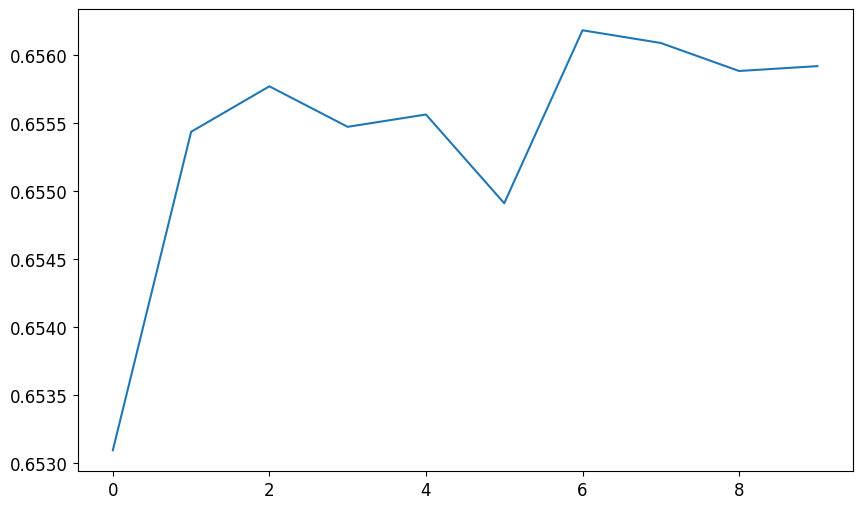

In [70]:
Exp = BM26_experiment(r'F:\SC_5732\RAW_DATA\LL_samples\LL_samples_LL_202_020')

plt.plot(Exp.get_Tr_profile())

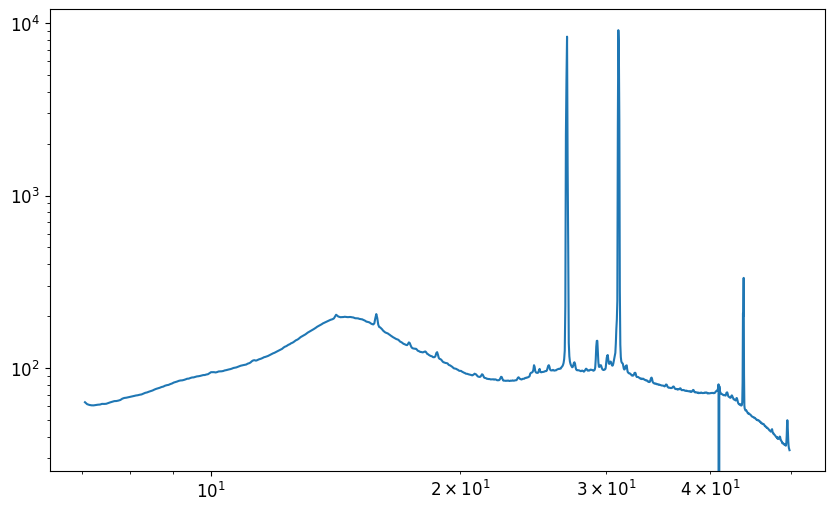

In [71]:
q, I_array = Exp.integrate1d_WAXS(ai_WAXS, 1000, mask=img_mask_WAXS, unit='q_nm^-1')
I = average(I_array)
plt.semilogx()
plt.semilogy()

plt.plot(q, I)

In [72]:
df = pd.DataFrame({'q': q, 'I':I})

df.to_csv(r'F:\SC_5732\RAW_DATA\LL_samples\Integrated\LL_202_WAXS.txt', sep=str('\t'), index=False)